In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para que las gráficas se vean bien
sns.set_theme(style="whitegrid")

# 1. Cargar el dataset (subimos un nivel con '..' y entramos a 'data')
df = pd.read_csv('../data/netflix_titles.csv')

# 2. Ver las primeras 5 filas para entender qué columnas tenemos
print("--- Vista Previa ---")
display(df.head())

# 3. Ver el resumen técnico (tipos de datos y NULOS)
print("\n--- Información del Dataset ---")
df.info()

--- Vista Previa ---


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...



--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [4]:
# --- LIMPIEZA DE DATOS ---

# 1. Manejo de Nulos (Imputación)
# No podemos inventar el nombre del director, así que llenaremos los vacíos con "Desconocido"
# Esto es mejor que borrar la fila, porque no perdemos la información de la película.
df['director'] = df['director'].fillna('Sin Director')
df['country'] = df['country'].fillna('Sin País')
df['cast'] = df['cast'].fillna('Sin Elenco')
df['rating'] = df['rating'].fillna('Sin Clasificación')

# 2. Eliminar datos críticos faltantes
# Si no tiene fecha de agregado, no nos sirve para el análisis de tiempo.
# Como vimos que solo faltan 10 (7787 vs 7777), las borramos sin miedo.
df = df.dropna(subset=['date_added'])

# 3. Conversión de Tipos (Casting)
# Convertimos la columna 'date_added' de Texto a Fecha real
# .str.strip() quita espacios vacíos al inicio o final que suelen dar error
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

# 4. Verificación Final
print("--- Estructura después de la limpieza ---")
df.info()

--- Estructura después de la limpieza ---
<class 'pandas.core.frame.DataFrame'>
Index: 7777 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7777 non-null   object        
 1   type          7777 non-null   object        
 2   title         7777 non-null   object        
 3   director      7777 non-null   object        
 4   cast          7777 non-null   object        
 5   country       7777 non-null   object        
 6   date_added    7777 non-null   datetime64[ns]
 7   release_year  7777 non-null   int64         
 8   rating        7777 non-null   object        
 9   duration      7777 non-null   object        
 10  listed_in     7777 non-null   object        
 11  description   7777 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 789.9+ KB


C:\Users\pardo\AppData\Local\Temp\ipykernel_15328\282577725.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='type', palette='Set2')


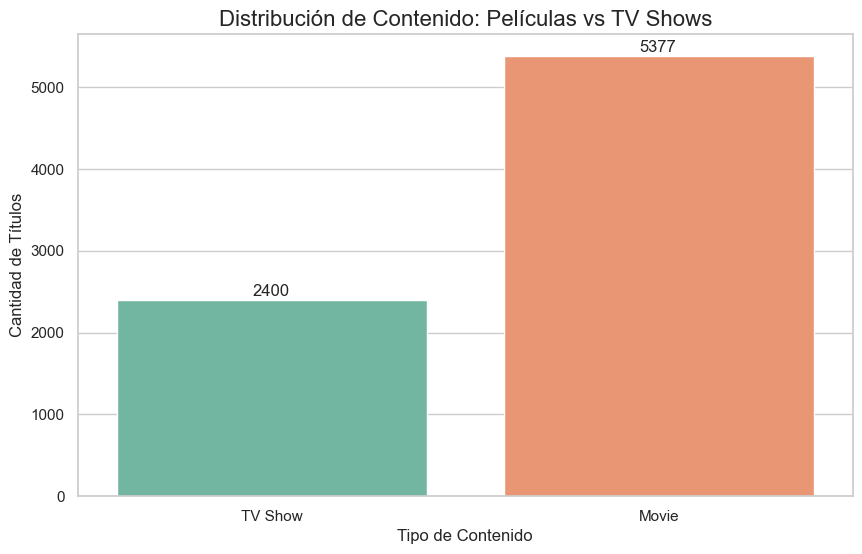

In [5]:
# --- PREGUNTA 1: ¿Cuál es nuestra estrategia principal? ¿Estamos enfocados en producir Películas o Series de TV? ---

plt.figure(figsize=(10, 6)) # Tamaño del cuadro (ancho, alto)

# Usamos Seaborn para contar automáticamente cuántas hay de cada tipo
ax = sns.countplot(data=df, x='type', palette='Set2')

plt.title('Distribución de Contenido: Películas vs TV Shows', fontsize=16)
plt.xlabel('Tipo de Contenido')
plt.ylabel('Cantidad de Títulos')

# Añadir las etiquetas de números exactos encima de las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 50))

plt.show()

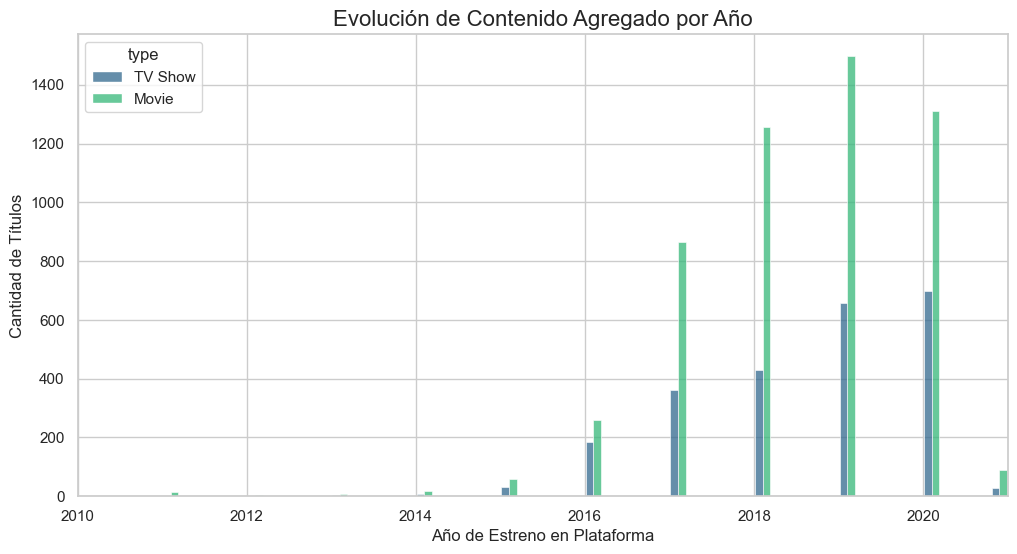

In [9]:
# --- PREGUNTA 2: ¿Cómo ha evolucionado el contenido por año? ---

# 1. Extraemos el AÑO de la fecha de agregado
df['year_added'] = df['date_added'].dt.year

# 2. Preparamos el gráfico de líneas (Time Series)
plt.figure(figsize=(12, 6))

# Usamos 'histplot' para ver la acumulación por año, separado por tipo
sns.histplot(data=df, x='year_added', hue='type', multiple='dodge', shrink=0.9, palette='viridis')

plt.title('Evolución de Contenido Agregado por Año', fontsize=16)
plt.xlabel('Año de Estreno en Plataforma')
plt.ylabel('Cantidad de Títulos')
plt.xlim(2010, 2021) # Nos enfocamos en la década relevante

plt.show()

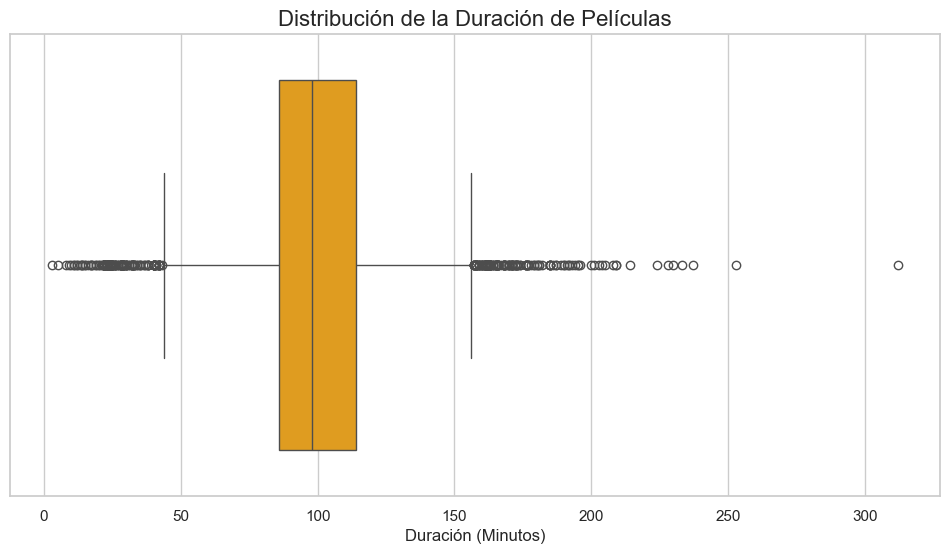

Estadisticas de duración:
count    5377.000000
mean       99.307978
std        28.530881
min         3.000000
25%        86.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_min, dtype: float64


In [12]:
# --- ¿Cuanto duran las pelicuilas realmente? ---

# 1. Filtramos SOLO las peliculas (porque las series se miden en temporadas, no minutos)
movies_df = df[df['type'] == 'Movie'].copy()

# 2. Limpieza: La columna 'duration' es texto (ej: "90 min")
#    Necesitamos quitar la palabra "min" y convertir el numero a entero
movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '').astype(int)

# 3. Graficamos la distribución
plt.figure(figsize=(12, 6))

#Boxplot: La caja muestra donde esta la mayoria de las peliculas
sns.boxplot(data=movies_df, x='duration_min', color='orange')

plt.title('Distribución de la Duración de Películas', fontsize=16)
plt.xlabel('Duración (Minutos)')
plt.show()

# Dato Extra: Ver las estadisticas exactas
print("Estadisticas de duración:")
print(movies_df['duration_min'].describe())

In [13]:
# --- GUARDADO AUTOMÁTICO DE GRÁFICAS PARA EL REPORTE ---
import os

# Aseguramos que la carpeta reports exista
folder_path = '../reports'
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# 1. Gráfica de Distribución (Películas vs Series)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='type', palette='Set2')
plt.title('Distribución de Contenido')
plt.savefig(f'{folder_path}/1_distribucion.png') # 
plt.close() # Cierra para no mostrarla otra vez

# 2. Gráfica de Evolución (Time Series)
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='year_added', hue='type', multiple='dodge', shrink=0.8, palette='viridis')
plt.title('Evolución de Contenido por Año')
plt.xlim(2010, 2021)
plt.savefig(f'{folder_path}/2_evolucion_temporal.png')
plt.close()

# 3. Gráfica de Duración (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(data=movies_df, x='duration_min', color='orange')
plt.title('Distribución de Duración de Películas')
plt.savefig(f'{folder_path}/3_duracion_boxplot.png')
plt.close()

print("✅ ¡Listo! Las 3 imágenes se guardaron en la carpeta 'reports'.")

C:\Users\pardo\AppData\Local\Temp\ipykernel_15328\456095253.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


✅ ¡Listo! Las 3 imágenes se guardaron en la carpeta 'reports'.
